<a href="https://colab.research.google.com/github/vivsingh119/agentic-ai-practise/blob/master/Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [308]:
import numpy as nb;
import pandas as pd;
import matplotlib.pyplot as plt
import seaborn as sns

In [309]:
pd.DataFrame({"S1":[21,22,26,28],"s2":[23,20,29,28]})

,S1,s2
0,21,23
1,22,20
2,26,29
3,28,28


In [310]:
irisData=pd.read_csv("Iris_missingdata.csv")
irisData

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,NaN,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,NaN,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [311]:
irisData.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [312]:
irisData.isna().sum()

,0
Id,0
SepalLengthCm,11
SepalWidthCm,7
PetalLengthCm,8
PetalWidthCm,9
Species,0


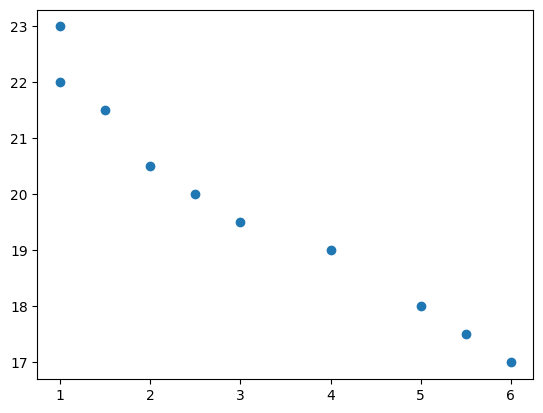

In [313]:
data=pd.DataFrame({"S1":[1,1,1.5,2,2.5,3,4,5,5.5,6],"s2":[23,22,21.5,20.5,20,19.5,19,18,17.5,17]})
plt.plot(data["S1"],data["s2"],"o")


In [314]:

sampleData.count()

,0
Height,25000
Weight,25000


In [315]:
sampleData.isna().sum()

,0
Height,0
Weight,0


In [316]:
sampleData=pd.read_csv("HeightWeight.csv");
sampleData.head()

,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971


In [317]:
#Drop index column from sample Data
sampleData.drop("Index", axis = 1, inplace = True)

In [318]:
sampleData

,Height(Inches),Weight(Pounds)
0,65.78331,112.9925
1,71.51521,136.4873
2,69.39874,153.0269
3,68.21660,142.3354
4,67.78781,144.2971
...,...,...
24995,69.50215,118.0312
24996,64.54826,120.1932
24997,64.69855,118.2655
24998,67.52918,132.2682


In [319]:
#remove Inches and pounds postfix from column header
sampleData.columns=["Height","Weight"]

In [320]:
sampleData

,Height,Weight
0,65.78331,112.9925
1,71.51521,136.4873
2,69.39874,153.0269
3,68.21660,142.3354
4,67.78781,144.2971
...,...,...
24995,69.50215,118.0312
24996,64.54826,120.1932
24997,64.69855,118.2655
24998,67.52918,132.2682


In [321]:
sampleData["Height"].describe()

,Height
count,25000.000000
mean,67.993114
std,1.901679
min,60.278360
25%,66.704397
50%,67.995700
75%,69.272958
max,75.152800


In [322]:
#find outlier from height column (if data are less than 25% percentile and graeter than75%, percentile ,consider as outlier)
q1,q2=sampleData["Height"].quantile([0.25,0.75])
print(q1,q2)

66.7043975 69.2729575


In [323]:
#Interpretation:
# Skew ≈ 0 → Normal Distribution.
# Skew ≈ ±1 → Skewed Distribution
sampleData['Height'].skew()

np.float64(-0.00565797936693913)

In [324]:
#Formula:
# Lower Limit (LL) = Mean – 3 × Std Dev.
# Upper Limit (UL) = Mean + 3 × Std Dev.
ll=sampleData["Height"].mean()-3*sampleData["Height"].std()
ul=sampleData["Height"].mean()+3*sampleData["Height"].std()
print(ll,ul)

62.28807728318317 73.6981499104168


In [325]:
  (sampleData['Height']<ll)| (sampleData['Height']>ul).count()

,Height
0,True
1,True
2,True
3,True
4,True
...,...
24995,True
24996,True
24997,True
24998,True


In [326]:
sampleData[(sampleData['Height']<ll)| (sampleData['Height']>ul)].count()

,0
Height,51
Weight,51


In [327]:
sampleData['Height']=sampleData['Height'].map(lambda x: ll if(x<ll) else ul if(x>ul) else x)


In [328]:
sampleData[(sampleData['Height']<ll)| (sampleData['Height']>ul)].count()

,0
Height,0
Weight,0


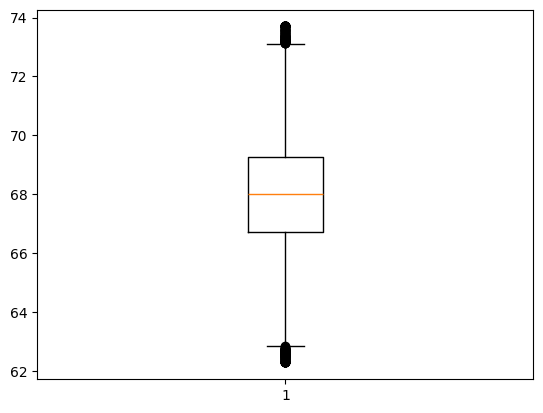

In [329]:
plt.boxplot(sampleData['Height'])
plt.show()

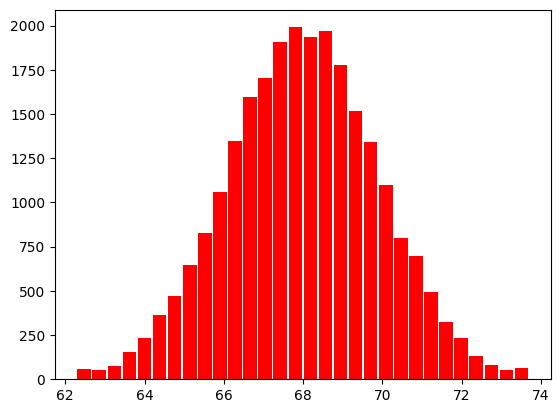

In [330]:
plt.hist(sampleData['Height'],bins=30,rwidth=0.9,color='red')
plt.show()

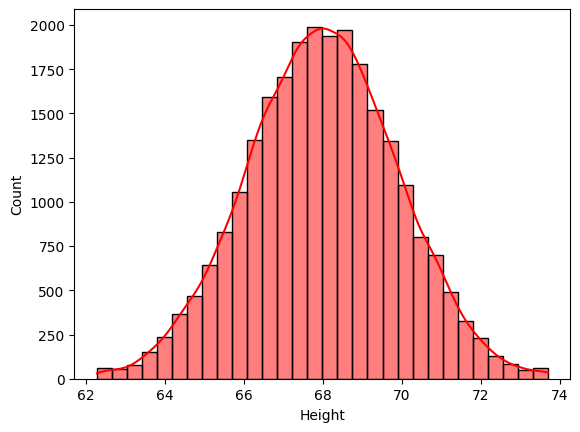

In [331]:
sns.histplot(sampleData['Height'],bins=30,kde=True, color="red",stat='count')
plt.show()



In [332]:
# now check from width column
sampleData['Weight'].skew().round()


np.float64(-0.0)

In [333]:
## its normal distrubution calculate lower and upper limit

In [334]:
lower=sampleData["Weight"].mean()-3*sampleData['Weight'].std();
upper=sampleData["Weight"].mean()+3*sampleData['Weight'].std();
print(lower,upper)

92.09672846998714 162.06211385161288


In [335]:
sampleData['Weight'][(sampleData['Weight']<lower)| (sampleData['Weight']>upper)].count()

np.int64(69)

In [336]:
sampleData['Weight']=sampleData['Weight'].map(lambda x: lower if(x<lower) else upper if(x>upper) else x)

In [337]:
sampleData['Weight'][(sampleData['Weight']<lower)| (sampleData['Weight']>upper)].count()


np.int64(0)

In [338]:
sampleData['Weight']

,Weight
0,112.9925
1,136.4873
2,153.0269
3,142.3354
4,144.2971
...,...
24995,118.0312
24996,120.1932
24997,118.2655
24998,132.2682


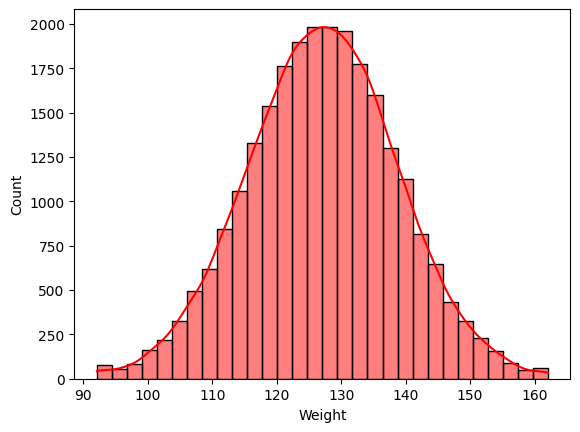

In [339]:
sns.histplot(sampleData['Weight'],bins=30,kde=True, color="red")
plt.show()

In [340]:
import numpy as nb;
import pandas as pd;
import matplotlib.pyplot as plt
import seaborn as sns

In [341]:
pd.DataFrame({"S1":[21,22,26,28],"s2":[23,20,29,28]})

,S1,s2
0,21,23
1,22,20
2,26,29
3,28,28


In [342]:
irisData=pd.read_csv("Iris_missingdata.csv")
irisData

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,NaN,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,NaN,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [343]:
irisData.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [344]:
irisData.isna().sum()

,0
Id,0
SepalLengthCm,11
SepalWidthCm,7
PetalLengthCm,8
PetalWidthCm,9
Species,0


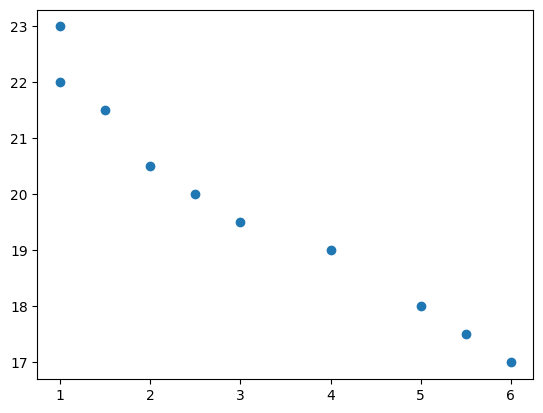

In [345]:
data=pd.DataFrame({"S1":[1,1,1.5,2,2.5,3,4,5,5.5,6],"s2":[23,22,21.5,20.5,20,19.5,19,18,17.5,17]})
plt.plot(data["S1"],data["s2"],"o")


In [346]:

sampleData.count()

,0
Height,25000
Weight,25000


In [347]:
sampleData.isna().sum()

,0
Height,0
Weight,0


In [348]:
sampleData=pd.read_csv("HeightWeight.csv");
sampleData.head()

,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971


In [349]:
#Drop index column from sample Data
sampleData.drop("Index", axis = 1, inplace = True)

In [350]:
sampleData

,Height(Inches),Weight(Pounds)
0,65.78331,112.9925
1,71.51521,136.4873
2,69.39874,153.0269
3,68.21660,142.3354
4,67.78781,144.2971
...,...,...
24995,69.50215,118.0312
24996,64.54826,120.1932
24997,64.69855,118.2655
24998,67.52918,132.2682


In [351]:
#remove Inches and pounds postfix from column header
sampleData.columns=["Height","Weight"]

In [352]:
sampleData

,Height,Weight
0,65.78331,112.9925
1,71.51521,136.4873
2,69.39874,153.0269
3,68.21660,142.3354
4,67.78781,144.2971
...,...,...
24995,69.50215,118.0312
24996,64.54826,120.1932
24997,64.69855,118.2655
24998,67.52918,132.2682


In [353]:
sampleData["Height"].describe()

,Height
count,25000.000000
mean,67.993114
std,1.901679
min,60.278360
25%,66.704397
50%,67.995700
75%,69.272958
max,75.152800


In [354]:
#find outlier from height column (if data are less than 25% percentile and graeter than75%, percentile ,consider as outlier)
q1,q2=sampleData["Height"].quantile([0.25,0.75])
print(q1,q2)

66.7043975 69.2729575


In [355]:
#Interpretation:
# Skew ≈ 0 → Normal Distribution.
# Skew ≈ ±1 → Skewed Distribution
sampleData['Height'].skew()

np.float64(-0.00565797936693913)

In [356]:
#Formula:
# Lower Limit (LL) = Mean – 3 × Std Dev.
# Upper Limit (UL) = Mean + 3 × Std Dev.
ll=sampleData["Height"].mean()-3*sampleData["Height"].std()
ul=sampleData["Height"].mean()+3*sampleData["Height"].std()
print(ll,ul)

62.28807728318317 73.6981499104168


In [357]:
  (sampleData['Height']<ll)| (sampleData['Height']>ul).count()

,Height
0,True
1,True
2,True
3,True
4,True
...,...
24995,True
24996,True
24997,True
24998,True


In [358]:
sampleData[(sampleData['Height']<ll)| (sampleData['Height']>ul)].count()

,0
Height,51
Weight,51


In [359]:
sampleData['Height']=sampleData['Height'].map(lambda x: ll if(x<ll) else ul if(x>ul) else x)


In [360]:
sampleData[(sampleData['Height']<ll)| (sampleData['Height']>ul)].count()

,0
Height,0
Weight,0


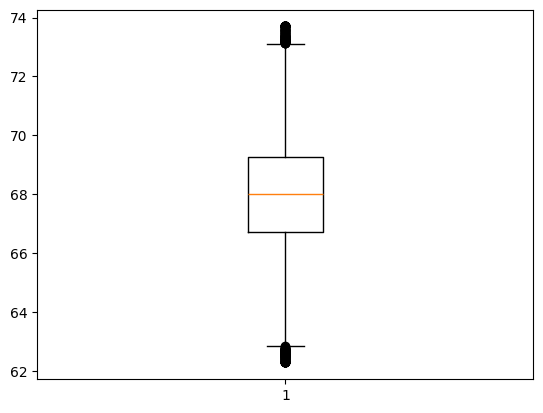

In [361]:
plt.boxplot(sampleData['Height'])
plt.show()

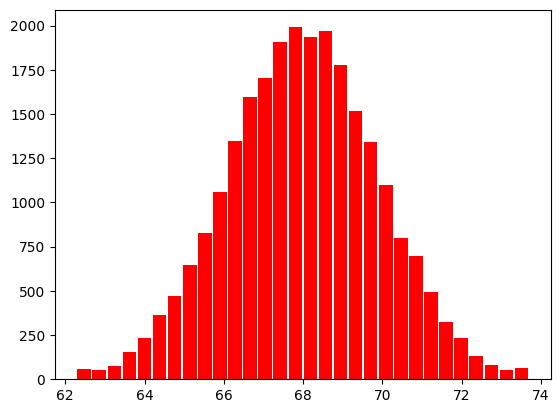

In [362]:
plt.hist(sampleData['Height'],bins=30,rwidth=0.9,color='red')
plt.show()

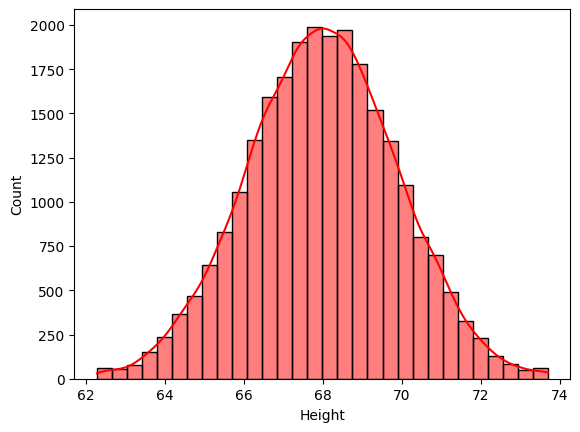

In [363]:
sns.histplot(sampleData['Height'],bins=30,kde=True, color="red",stat='count')
plt.show()



In [364]:
# now check from width column
sampleData['Weight'].skew().round()


np.float64(-0.0)

In [365]:
## its normal distrubution calculate lower and upper limit

In [366]:
lower=sampleData["Weight"].mean()-3*sampleData['Weight'].std();
upper=sampleData["Weight"].mean()+3*sampleData['Weight'].std();
print(lower,upper)

92.09672846998714 162.06211385161288


In [367]:
sampleData['Weight'][(sampleData['Weight']<lower)| (sampleData['Weight']>upper)].count()

np.int64(69)

In [368]:
sampleData['Weight']=sampleData['Weight'].map(lambda x: lower if(x<lower) else upper if(x>upper) else x)

In [369]:
sampleData['Weight'][(sampleData['Weight']<lower)| (sampleData['Weight']>upper)].count()


np.int64(0)

In [370]:
sampleData['Weight']

,Weight
0,112.9925
1,136.4873
2,153.0269
3,142.3354
4,144.2971
...,...
24995,118.0312
24996,120.1932
24997,118.2655
24998,132.2682


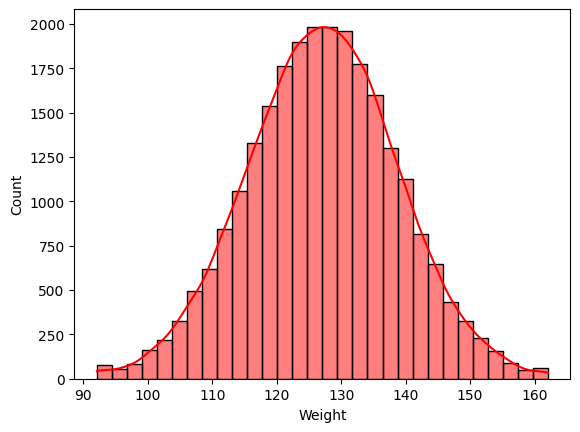

In [371]:
sns.histplot(sampleData['Weight'],bins=30,kde=True, color="red")
plt.show()

# New Section

# New Section